 # 1. Title and objective
 This notebook presents a structured exploratory review of the Ames Housing dataset. The objective is to document data loading, variable profiling, metadata parsing, missing-value inspection, and numerical quality reporting in a readable analytical sequence.


 ## 2. Imports and setup
 The following imports provide the core tools used for data handling and text parsing in the initial stages of the notebook.


In [1]:

import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error

 ## 3. Data loading
 The dataset is loaded from the project data directory and an initial preview is displayed.


In [2]:
data_path= '../data/raw/AmesHousing.csv'

df = pd.read_csv(data_path)

df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=40
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2051, 81) (2051,)
Validation: (439, 81) (439,)
Test: (440, 81) (440,)


In [4]:
df_train = df.loc[X_train.index]

 ## 4. Initial dataset overview
 The next outputs summarize the dataset dimensions and a general descriptive overview of the available variables.


In [5]:
print(f'Dataset shape: {df.shape} :')

Dataset shape: (2930, 82) :


In [6]:
df.describe()


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


 ## 5. Variable profiling table
 This section constructs a compact profiling table for all variables, including completeness, cardinality, type, and simple count summaries.


In [7]:
def summary_profiling_table(df: pd.DataFrame) -> pd.DataFrame:
    summary = []

    for col in df.columns:
        series = df[col]

        summary.append({
            "variable": col,
            "num_of_values": series.notna().sum(),
            "pct_missing": series.isna().mean() * 100,
            "unique_values": series.nunique(dropna=True),
            "mean": series.mean() if pd.api.types.is_numeric_dtype(series) else np.nan,
            "python_type": str(series.dtype),
            "inferred_type": pd.api.types.infer_dtype(series, skipna=True)
        })

    return pd.DataFrame(summary).sort_values(
        by=["pct_missing", "unique_values"],
        ascending=[False, False]
    ).reset_index(drop=True)

 ## 6. Metadata loading and parsing
The metadata file is parsed into a tabular structure to support comparison between documented variables and observed dataset fields.


In [8]:

def load_metadata_table(filepath: str) -> pd.DataFrame:
    """
    Parse Ames Housing metadata file and return a structured table
    with Variable Name, Variable Type, and Description.

    Parameters
    ----------
    filepath : str
        Path to metadata.txt file.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - Variable
        - Type
        - Description
    """

    variables = []

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    pattern = re.compile(r"^(.+?)\s*\((Nominal|Ordinal|Discrete|Continuous)\):\s*(.+)")

    for line in lines:
        match = pattern.match(line.strip())
        if match:
            var_name = match.group(1).strip()
            var_type = match.group(2).strip()
            description = match.group(3).strip()

            variables.append({
                "Variable": var_name,
                "Type": var_type,
                "Description": description
            })

    df = pd.DataFrame(variables)

    return df

In [9]:
metadata_df = load_metadata_table("../metada.txt")

In [10]:
metadata_df


,Variable,Type,Description
0,Order,Discrete,Observation number
1,PID,Nominal,Parcel identification number - can be used wi...
2,MS SubClass,Nominal,Identifies the type of dwelling involved in th...
3,MS Zoning,Nominal,Identifies the general zoning classification o...
4,Lot Frontage,Continuous,Linear feet of street connected to property
...,...,...,...
75,Mo Sold,Discrete,Month Sold (MM)
76,Yr Sold,Discrete,Year Sold (YYYY)
77,Sale Type,Nominal,Type of sale
78,Sale Condition,Nominal,Condition of sale


 ## 7. Missing values overview
 The following cells identify columns with missing values and provide a concise overview of their presence in the dataset.


In [11]:
def missing_columns(df):
    """
    Retorna uma lista de colunas ordenadas
    do maior número de missing values para o menor.
    """

    missing = (
        df.isna()
          .sum()                # conta missing por coluna
          .sort_values(ascending=False)  # ordena (maior → menor)
    )

    # mantém apenas colunas com missing
    missing = missing[missing > 0]

    return missing.index.tolist()

In [12]:
missing=missing_columns(df)

In [13]:
print(missing)

['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu', 'Lot Frontage', 'Garage Qual', 'Garage Yr Blt', 'Garage Cond', 'Garage Finish', 'Garage Type', 'Bsmt Exposure', 'BsmtFin Type 2', 'Bsmt Qual', 'Bsmt Cond', 'BsmtFin Type 1', 'Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Total Bsmt SF', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Garage Area', 'Garage Cars', 'Bsmt Unf SF', 'Electrical']


In [14]:
len(missing)


27

 ## 8. Detailed inspection of columns with missing values
 This inspection step lists value frequencies and unique entries for each variable that contains missing observations.


In [15]:
for col in df.columns:
    if col in missing:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False))
        print(df[col].unique())


===== Lot Frontage =====
Lot Frontage
NaN      490
60.0     276
80.0     137
70.0     133
50.0     117
        ... 
168.0      1
111.0      1
131.0      1
153.0      1
133.0      1
Name: count, Length: 129, dtype: int64
[141.  80.  81.  93.  74.  78.  41.  43.  39.  60.  75.  nan  63.  85.
  47. 152.  88. 140. 105.  65.  70.  26.  21.  53.  24. 102.  98.  83.
  94.  95.  90.  79. 100.  44. 110.  61.  36.  67. 108.  59.  92.  58.
  56.  73.  72.  84.  76.  50.  55.  68. 107.  25.  30.  57.  40.  77.
 120. 137.  87. 119.  64.  96.  71.  69.  52.  51.  54.  86. 124.  82.
  38.  48.  89.  66.  45.  35. 129.  31.  42.  28.  99. 104.  97. 103.
  34. 117. 149. 122.  62. 174. 106. 112.  32. 115. 128.  91.  33. 121.
 144. 130. 109. 150. 113. 125. 101.  46. 114. 135. 136.  37.  22. 313.
  49. 123. 160. 195. 118. 134. 182. 116. 138. 155. 126. 200. 168. 111.
 131. 153. 133.]

===== Alley =====
Alley
NaN     2732
Grvl     120
Pave      78
Name: count, dtype: int64
<StringArray>
[nan, 'Pave', 'Grvl

 ## 9. Structural vs non-structural missing values
 This section separates missing values that are structurally justified by metadata or variable families from those without such justification.


In [16]:

def extrair_variaveis_com_na(metadata_texto, df):
    """
    Retorna duas listas a partir das variáveis com NaN no dataset:
    - estrutural: NA justificado pelo metadata (explícito) OU pertence
                  à família Bsmt/Garage/MasVnr (implícito por proximidade)
    - nao_justificado: NaN sem qualquer justificação no metadata
    """
    variavel_pattern = re.compile(r'^([\w\s./-]+)\s*\([^\)]+\)\s*:', re.MULTILINE)
    na_pattern = re.compile(r'^\s*(NA|None)(\s|$)', re.MULTILINE)
    blocos = re.split(r'\n(?=\S[\w\s./-]*\s*\([^\)]+\)\s*:)', metadata_texto)

    # NA explícito no metadata
    na_explicito = []
    for bloco in blocos:
        m = variavel_pattern.match(bloco)
        if m and na_pattern.search(bloco):
            na_explicito.append(m.group(1).strip())

    # Famílias com NA implícito por proximidade
    familias = [r'(?i)bsmt', r'(?i)basement', r'(?i)garage', r'(?i)mas.?vnr']

    vars_com_nan = [col for col in df.columns if df[col].isna().any()]

    estrutural, nao_justificado = [], []
    for var in vars_com_nan:
        if var in na_explicito or any(re.search(p, var) for p in familias):
            estrutural.append(var)
        else:
            nao_justificado.append(var)

    return estrutural, nao_justificado


# Uso
with open("../metada.txt", "r", encoding="utf-8") as f:
    metadata_texto = f.read()

estrutural, nao_justificado = extrair_variaveis_com_na(metadata_texto, df)
  # → ['Lot Frontage', 'Electrical']
estrutural.append('Fireplace Qu')
nao_justificado.remove('Fireplace Qu')
print("Estrutural (justificado):", estrutural)
print("Não justificado:", nao_justificado)

Estrutural (justificado): ['Alley', 'Mas Vnr Type', 'Mas Vnr Area', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature', 'Fireplace Qu']
Não justificado: ['Lot Frontage', 'Electrical']


 ## 10. Targeted assessment of MCAR plausibility
 A targeted statistical procedure is defined below to examine whether selected missingness patterns are compatible with an MCAR assumption.


In [17]:


def test_mcar_targeted(df, target_var, candidate_predictors, verbose=True):
    """
    Tests MCAR for target_var using only theoretically motivated predictors.
    Much more reliable than kitchen-sink logistic regression.

    Returns dict with test results and interpretation.
    """
    df = df.copy()

    missing_indicator = df[target_var].isna().astype(int)
    n_missing = missing_indicator.sum()

    if n_missing < 10:
        return {
            "target": target_var,
            "verdict": "SKIP — too few missing values for reliable test",
            "n_missing": n_missing,
            "recommendation": "Assume MCAR, impute with mode/median"
        }

    results = {"target": target_var, "n_missing": n_missing, "tests": {}}

    for pred in candidate_predictors:
        if pred not in df.columns:
            continue

        col = df[pred]

        # Numeric: compare mean between missing vs non-missing (t-test)
        if pd.api.types.is_numeric_dtype(col):
            group0 = col[missing_indicator == 0].dropna()
            group1 = col[missing_indicator == 1].dropna()
            if len(group1) < 5:
                continue
            stat, p = stats.ttest_ind(group0, group1)
            results["tests"][pred] = {
                "test": "t-test",
                "mean_present": group0.mean(),
                "mean_missing": group1.mean(),
                "p_value": p
            }

        # Categorical: chi-square test of independence
        else:
            ct = pd.crosstab(col, missing_indicator)
            if ct.shape[0] < 2:
                continue
            chi2, p, dof, _ = stats.chi2_contingency(ct)
            results["tests"][pred] = {
                "test": "chi2",
                "chi2": chi2,
                "p_value": p
            }

    # Summarize
    sig = {k: v for k, v in results["tests"].items() if v["p_value"] < 0.05}
    results["significant_predictors"] = list(sig.keys())
    results["verdict"] = "MAR (not MCAR)" if sig else "Cannot reject MCAR"

    if verbose:
        print(f"\n{'='*50}")
        print(f"Variable: {target_var}  |  Missing: {n_missing} ({n_missing/len(df):.1%})")
        print(f"Verdict: {results['verdict']}")
        for pred, t in results["tests"].items():
            flag = " *** SIGNIFICANT" if t["p_value"] < 0.05 else ""
            print(f"  {pred}: p={t['p_value']:.4f}{flag}")

    return results


# ── Apply ──────────────────────────────────────────────────────────────────

hypotheses = {
    "Lot Frontage": ["Lot Config", "Lot Shape", "Neighborhood", "Bldg Type", "MS SubClass"],
    "Electrical":   []  # skip — only 1 missing
}

for var, preds in hypotheses.items():
    if not preds:
        print(f"\nElectrical: 1 missing value → assume MCAR, impute with mode")
        continue
    test_mcar_targeted(df, var, preds)


Variable: Lot Frontage  |  Missing: 490 (16.7%)
Verdict: MAR (not MCAR)
  Lot Config: p=0.0000 *** SIGNIFICANT
  Lot Shape: p=0.0000 *** SIGNIFICANT
  Neighborhood: p=0.0000 *** SIGNIFICANT
  Bldg Type: p=0.0065 *** SIGNIFICANT
  MS SubClass: p=0.2753

Electrical: 1 missing value → assume MCAR, impute with mode


 ## 11. Numerical variables quality report
 The next cells isolate numerical variables and generate descriptive quality indicators, including dispersion and distribution-shape measures.


In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [19]:

def numeric_quality_report(df):

    numeric_df = df.select_dtypes(include=[np.number])

    summary = []

    for col in numeric_df.columns:
        s = numeric_df[col].dropna()

        if len(s) == 0:
            continue

        mean_val = s.mean()
        median_val = s.median()
        std_val = s.std()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        cv_val = std_val / mean_val
        iqr_val = q3 - q1
        skew_val = skew(s, bias=False)
        kurt_val = kurtosis(s, bias=False)  # excess kurtosis

        summary.append({
            "variable": col,
            "n": len(s),
            "mean": mean_val,
            "median": median_val,
            "mean_minus_median": mean_val - median_val,
            "std": std_val,
            "cv": cv_val,
            "IQR": iqr_val,
            "skewness": skew_val,
            "kurtosis_excess": kurt_val
        })

    result = pd.DataFrame(summary)

    # Opcional: ordenar por assimetria absoluta
    result = result.sort_values("skewness", key=lambda x: abs(x), ascending=False)

    return result

In [20]:
numeric_report = numeric_quality_report(df_train)
numeric_report.head(10)

,variable,n,mean,median,mean_minus_median,std,cv,IQR,skewness,kurtosis_excess
35,Misc Val,2051,45.358849,0.0,45.358849,498.589036,10.992101,0.0,23.726035,710.705083
34,Pool Area,2051,2.672355,0.0,2.672355,38.852867,14.538812,0.0,15.626586,255.892820
4,Lot Area,2051,10248.949293,9457.0,791.949293,8784.744906,0.857136,4170.0,12.880506,243.110266
16,Low Qual Fin SF,2051,5.038030,0.0,5.038030,48.700333,9.666542,0.0,12.102316,177.629581
32,3Ssn Porch,2051,1.965870,0.0,1.965870,19.562229,9.950925,0.0,10.679122,120.668880
23,Kitchen AbvGr,2051,1.039980,1.0,0.039980,0.200878,0.193156,0.0,4.333971,19.138169
11,BsmtFin SF 2,2050,48.893659,0.0,48.893659,168.372085,3.443639,0.0,4.258582,20.396545
19,Bsmt Half Bath,2049,0.059053,0.0,0.059053,0.241915,4.096556,0.0,4.051077,15.976830
33,Screen Porch,2051,15.552901,0.0,15.552901,55.430726,3.564012,0.0,3.961268,17.261049
31,Enclosed Porch,2051,23.150658,0.0,23.150658,61.193282,2.643263,0.0,2.941852,9.381007


In [21]:
numeric_report.info()

<class 'pandas.DataFrame'>
Index: 39 entries, 35 to 0
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   variable           39 non-null     str    
 1   n                  39 non-null     int64  
 2   mean               39 non-null     float64
 3   median             39 non-null     float64
 4   mean_minus_median  39 non-null     float64
 5   std                39 non-null     float64
 6   cv                 39 non-null     float64
 7   IQR                39 non-null     float64
 8   skewness           39 non-null     float64
 9   kurtosis_excess    39 non-null     float64
dtypes: float64(8), int64(1), str(1)
memory usage: 3.4 KB


 ## 12. Interpretation layer for numerical quality
 This layer assigns compact qualitative labels to the numerical quality metrics computed in the previous section.


In [22]:
def interpret_numeric_quality(df_report):
    """
    Recebe o dataframe do numeric_quality_report e adiciona colunas interpretativas
    para mean_minus_median, CV, skewness e kurtosis_excess.
    """
    import numpy as np

    report = df_report.copy()

    # --- Mean vs Median ---
    def mean_median_label(x, tol=1e-6):
        if pd.isna(x):
            return np.nan
        elif abs(x) < tol:
            return "Mean and median are approximately equal"
        elif x > 0:
            return "Mean greater than median (suggests positive skew)"
        else:
            return "Mean lower than median (suggests negative skew)"

    report["Mean_vs_median_interpretation"] = report["mean_minus_median"].apply(mean_median_label)

    # --- CV ---
    def cv_label(cv):
        if pd.isna(cv):
            return np.nan
        elif cv < 0.3:
            return "Low variability"
        elif cv < 0.7:
            return "Moderate variability"
        else:
            return "High variability"

    report["CV_interpretation"] = report["cv"].apply(cv_label)

    # --- Skewness ---
    def skew_label(sk):
        if pd.isna(sk):
            return np.nan

        abs_sk = abs(sk)

        if abs_sk < 0.5:
            magnitude = "Approximately symmetric"
        elif abs_sk < 1:
            magnitude = "Moderately skewed"
        else:
            magnitude = "Highly skewed"

        if sk > 0:
            direction = " (positive/right skew)"
        elif sk < 0:
            direction = " (negative/left skew)"
        else:
            direction = ""

        return magnitude + direction

    report["Skewness_interpretation"] = report["skewness"].apply(skew_label)

    # --- Kurtosis (excess kurtosis) ---
    def kurt_label(k):
        if pd.isna(k):
            return np.nan
        elif k < 0:
            return "Light tails (platykurtic)"
        elif abs(k) < 0.5:
            return "Approximately normal tails (mesokurtic)"
        elif k < 3:
            return "Moderately heavy tails"
        else:
            return "Heavy tails / extreme values"

    report["Kurtosis_interpretation"] = report["kurtosis_excess"].apply(kurt_label)

    # Selecionar colunas para interpretação
    interpretive_cols = [
        "variable",
        "mean",
        "median",
        "mean_minus_median",
        "Mean_vs_median_interpretation",
        "std",
        "cv",
        "CV_interpretation",
        "skewness",
        "Skewness_interpretation",
        "kurtosis_excess",
        "Kurtosis_interpretation"
    ]

    return report[interpretive_cols]

In [23]:
# Uso
numeric_report = numeric_quality_report(df_train)
numeric_interpretive = interpret_numeric_quality(numeric_report)
numeric_interpretive.head(39)


,variable,mean,median,mean_minus_median,Mean_vs_median_interpretation,std,cv,CV_interpretation,skewness,Skewness_interpretation,kurtosis_excess,Kurtosis_interpretation
35,Misc Val,4.535885e+01,0.0,4.535885e+01,Mean greater than median (suggests positive skew),4.985890e+02,10.992101,High variability,23.726035,Highly skewed (positive/right skew),710.705083,Heavy tails / extreme values
34,Pool Area,2.672355e+00,0.0,2.672355e+00,Mean greater than median (suggests positive skew),3.885287e+01,14.538812,High variability,15.626586,Highly skewed (positive/right skew),255.892820,Heavy tails / extreme values
4,Lot Area,1.024895e+04,9457.0,7.919493e+02,Mean greater than median (suggests positive skew),8.784745e+03,0.857136,High variability,12.880506,Highly skewed (positive/right skew),243.110266,Heavy tails / extreme values
16,Low Qual Fin SF,5.038030e+00,0.0,5.038030e+00,Mean greater than median (suggests positive skew),4.870033e+01,9.666542,High variability,12.102316,Highly skewed (positive/right skew),177.629581,Heavy tails / extreme values
32,3Ssn Porch,1.965870e+00,0.0,1.965870e+00,Mean greater than median (suggests positive skew),1.956223e+01,9.950925,High variability,10.679122,Highly skewed (positive/right skew),120.668880,Heavy tails / extreme values
23,Kitchen AbvGr,1.039980e+00,1.0,3.998050e-02,Mean greater than median (suggests positive skew),2.008781e-01,0.193156,Low variability,4.333971,Highly skewed (positive/right skew),19.138169,Heavy tails / extreme values
11,BsmtFin SF 2,4.889366e+01,0.0,4.889366e+01,Mean greater than median (suggests positive skew),1.683721e+02,3.443639,High variability,4.258582,Highly skewed (positive/right skew),20.396545,Heavy tails / extreme values
19,Bsmt Half Bath,5.905320e-02,0.0,5.905320e-02,Mean greater than median (suggests positive skew),2.419147e-01,4.096556,High variability,4.051077,Highly skewed (positive/right skew),15.976830,Heavy tails / extreme values
33,Screen Porch,1.555290e+01,0.0,1.555290e+01,Mean greater than median (suggests positive skew),5.543073e+01,3.564012,High variability,3.961268,Highly skewed (positive/right skew),17.261049,Heavy tails / extreme values
31,Enclosed Porch,2.315066e+01,0.0,2.315066e+01,Mean greater than median (suggests positive skew),6.119328e+01,2.643263,High variability,2.941852,Highly skewed (positive/right skew),9.381007,Heavy tails / extreme values


In [24]:
def overall_data_quality_table(numeric_report):

    results = []

    for _, row in numeric_report.iterrows():

        var = row["variable"]
        cv = row["cv"]
        skew = row["skewness"]
        kurt = row["kurtosis_excess"]

        # --- Validity assessment ---
        validity = "Likely valid and meaningful feature"

        # --- Modeling challenges ---
        challenges = []

        if cv >= 0.7:
            challenges.append("High dispersion")

        if abs(skew) >= 1:
            challenges.append("Strong skewness")
        elif abs(skew) >= 0.5:
            challenges.append("Moderate skewness")

        if kurt >= 3:
            challenges.append("Heavy tails")
        elif kurt > 0.5:
            challenges.append("Moderately heavy tails")

        if not challenges:
            modeling = "Statistically well-behaved"
        else:
            modeling = ", ".join(challenges)

        # --- Overall quality ---
        score = 0

        if cv >= 0.7:
            score += 1
        if abs(skew) >= 1:
            score += 1
        if kurt >= 3:
            score += 1

        if score == 0:
            overall = "High Quality"
        elif score == 1:
            overall = "Moderate Quality"
        else:
            overall = "Statistically Challenging"

        results.append({
            "variable": var,
            "validity_assessment": validity,
            "modeling_assessment": modeling,
            "overall_quality": overall
        })

    return pd.DataFrame(results)

In [25]:
quality_table = overall_data_quality_table(numeric_report)

quality_table

,variable,validity_assessment,modeling_assessment,overall_quality
0,Misc Val,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
1,Pool Area,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
2,Lot Area,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
3,Low Qual Fin SF,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
4,3Ssn Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
5,Kitchen AbvGr,Likely valid and meaningful feature,"Strong skewness, Heavy tails",Statistically Challenging
6,BsmtFin SF 2,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
7,Bsmt Half Bath,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
8,Screen Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging
9,Enclosed Porch,Likely valid and meaningful feature,"High dispersion, Strong skewness, Heavy tails",Statistically Challenging


In [26]:
def categorical_quality_report(df, rare_threshold=0.05):

    results = []

    cat_cols = df.select_dtypes(exclude="number").columns

    for col in cat_cols:

        s = df[col]

        counts = s.value_counts(dropna=False)
        rel_freq = s.value_counts(normalize=True, dropna=False)

        cardinality = s.nunique(dropna=True)

        dominant_pct = rel_freq.max() * 100

        rare_levels = rel_freq[rel_freq < rare_threshold]
        rare_count = len(rare_levels)

        rare_pct = rare_levels.sum() * 100

        missing_pct = s.isna().mean() * 100

        # --- imbalance evaluation ---
        if dominant_pct < 60:
            imbalance = "Balanced"
        elif dominant_pct < 80:
            imbalance = "Moderate imbalance"
        else:
            imbalance = "High imbalance"

        # --- cardinality evaluation ---
        if cardinality < 10:
            cardinality_level = "Low"
        elif cardinality <= 30:
            cardinality_level = "Moderate"
        else:
            cardinality_level = "High"

        # --- overall quality ---
        score = 0

        if dominant_pct > 80:
            score += 1

        if rare_count > 3:
            score += 1

        if cardinality > 30:
            score += 1

        if score == 0:
            overall = "High Quality"
        elif score == 1:
            overall = "Moderate Quality"
        else:
            overall = "Statistically Challenging"

        results.append({
            "variable": col,
            "cardinality": cardinality,
            "cardinality_level": cardinality_level,
            "dominant_pct": round(dominant_pct, 2),
            "rare_levels": rare_count,
            "rare_pct": round(rare_pct, 2),
            "missing_pct": round(missing_pct, 2),
            "imbalance": imbalance,
            "overall_quality": overall
        })

    return pd.DataFrame(results)

In [27]:
categorical_report = categorical_quality_report(df_train)

categorical_report

,variable,cardinality,cardinality_level,dominant_pct,rare_levels,rare_pct,missing_pct,imbalance,overall_quality
0,MS Zoning,7,Low,77.33,4,1.80,0.00,Moderate imbalance,Moderate Quality
1,Street,2,Low,99.51,1,0.49,0.00,High imbalance,Moderate Quality
2,Alley,2,Low,93.13,2,6.87,93.13,High imbalance,Moderate Quality
3,Lot Shape,4,Low,63.82,2,2.97,0.00,Moderate imbalance,High Quality
4,Land Contour,4,Low,90.20,3,9.80,0.00,High imbalance,Moderate Quality
5,Utilities,3,Low,99.85,2,0.15,0.00,High imbalance,Moderate Quality
6,Lot Config,5,Low,73.33,2,3.12,0.00,Moderate imbalance,High Quality
7,Land Slope,3,Low,95.17,2,4.83,0.00,High imbalance,Moderate Quality
8,Neighborhood,27,Moderate,14.14,19,38.32,0.00,Balanced,Moderate Quality
9,Condition 1,9,Low,86.49,7,7.75,0.00,High imbalance,Statistically Challenging


In [28]:
corr_pearson = df_train.corr(numeric_only=True)

corr_target_pearson = corr_pearson['SalePrice'].sort_values(ascending=False)
corr_target_pearson.head(20)

SalePrice         1.000000
Overall Qual      0.794599
Gr Liv Area       0.706756
Garage Cars       0.647357
Garage Area       0.638877
Total Bsmt SF     0.630081
1st Flr SF        0.619035
Year Built        0.556364
Full Bath         0.544779
Year Remod/Add    0.528362
Garage Yr Blt     0.517353
TotRms AbvGrd     0.508861
Mas Vnr Area      0.488971
Fireplaces        0.468932
BsmtFin SF 1      0.431856
Lot Frontage      0.372779
Wood Deck SF      0.330956
Open Porch SF     0.323232
Half Bath         0.302901
Bsmt Full Bath    0.271809
Name: SalePrice, dtype: float64

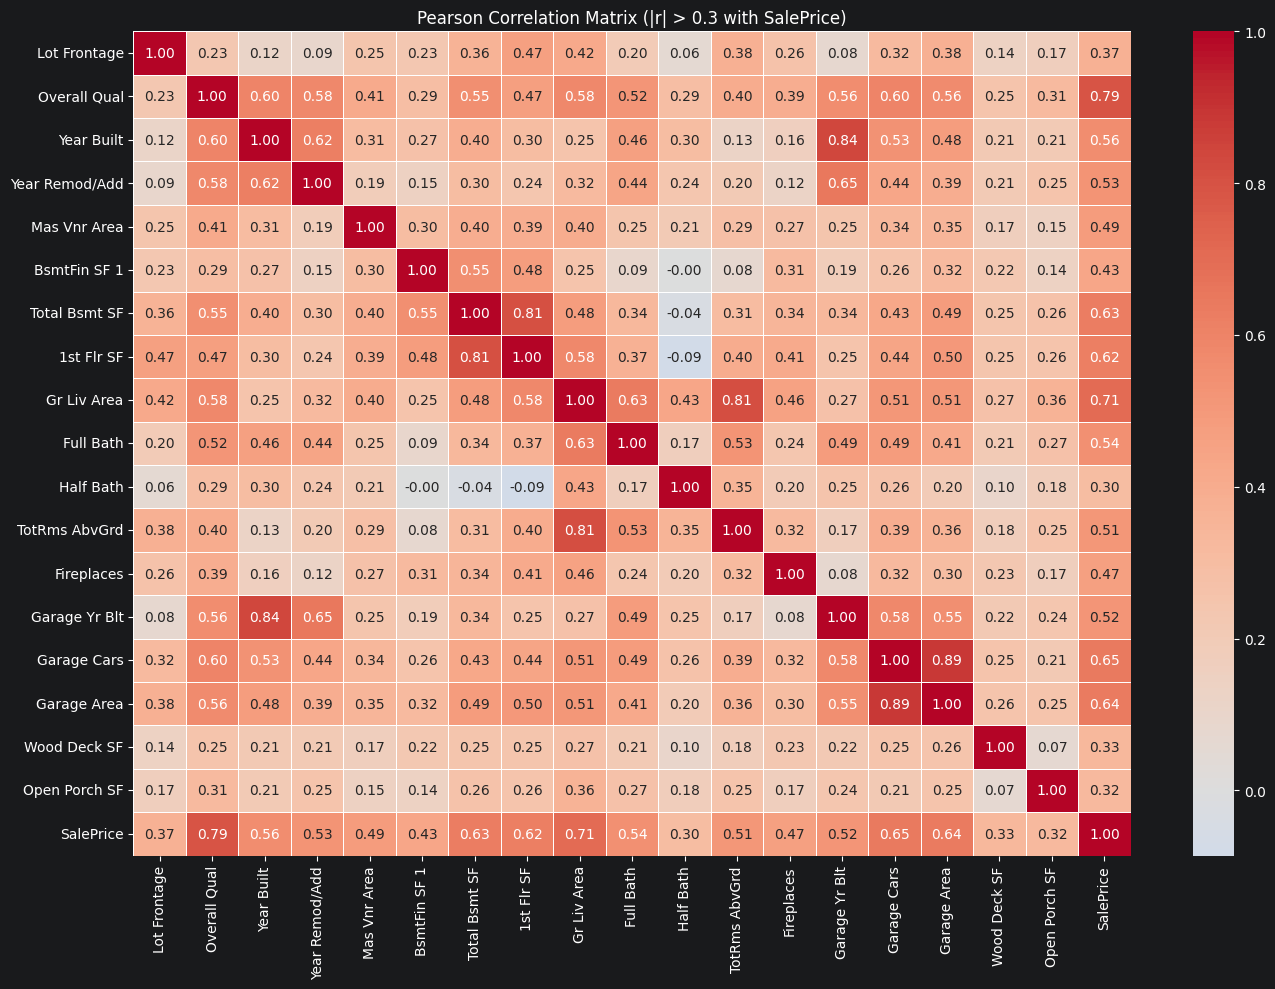

In [29]:
high_corr_cols = corr_pearson.index[corr_pearson['SalePrice'].abs() > 0.3].tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_pearson.loc[high_corr_cols, high_corr_cols],
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Pearson Correlation Matrix (|r| > 0.3 with SalePrice)")
plt.tight_layout()
plt.show()

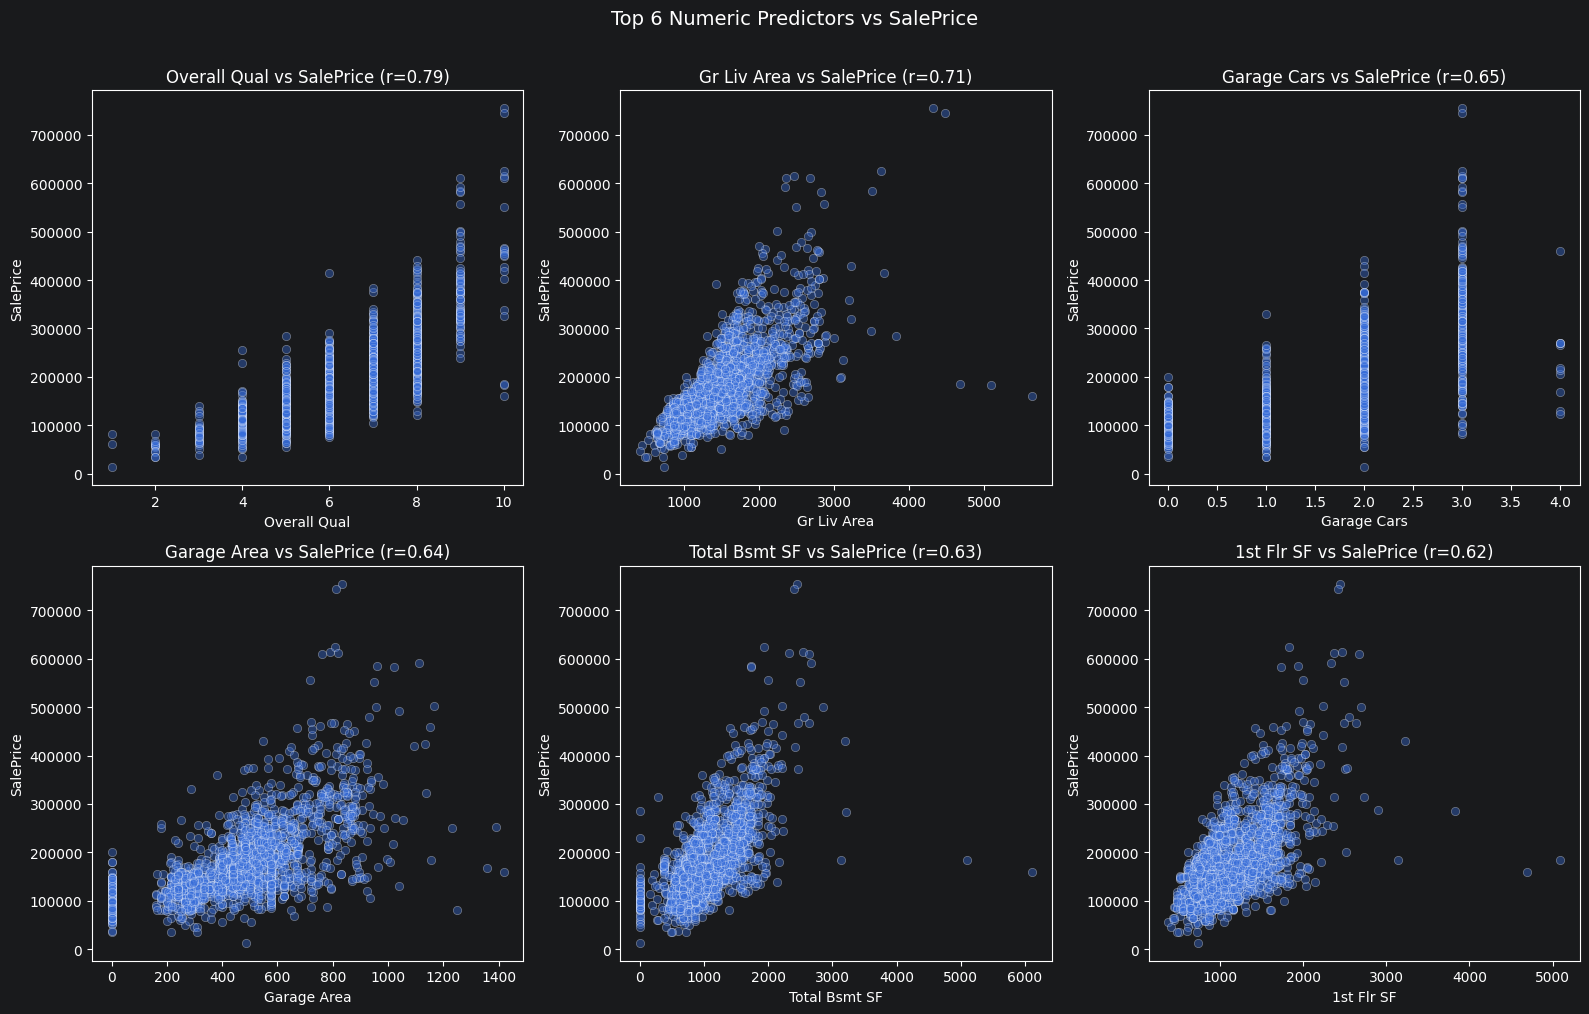

In [30]:
top_predictors = corr_target_pearson.drop('SalePrice').abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_predictors):
    sns.scatterplot(data=df_train, x=col, y='SalePrice', alpha=0.4, ax=axes[i])
    axes[i].set_title(f"{col} vs SalePrice (r={corr_target_pearson[col]:.2f})")

plt.suptitle("Top 6 Numeric Predictors vs SalePrice", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [31]:
corr_spearman = df_train.corr(method='spearman', numeric_only=True)

corr_target_spearman = corr_spearman['SalePrice'].sort_values(ascending=False)

comparison = pd.DataFrame({
    'Pearson': corr_target_pearson,
    'Spearman': corr_target_spearman
}).dropna().sort_values('Spearman', ascending=False)

comparison.head(20)

,Pearson,Spearman
SalePrice,1.000000,1.000000
Overall Qual,0.794599,0.810667
Gr Liv Area,0.706756,0.739750
Garage Cars,0.647357,0.704287
Year Built,0.556364,0.682485
Garage Area,0.638877,0.664748
Full Bath,0.544779,0.634788
Garage Yr Blt,0.517353,0.634446
Total Bsmt SF,0.630081,0.614623
Year Remod/Add,0.528362,0.598965


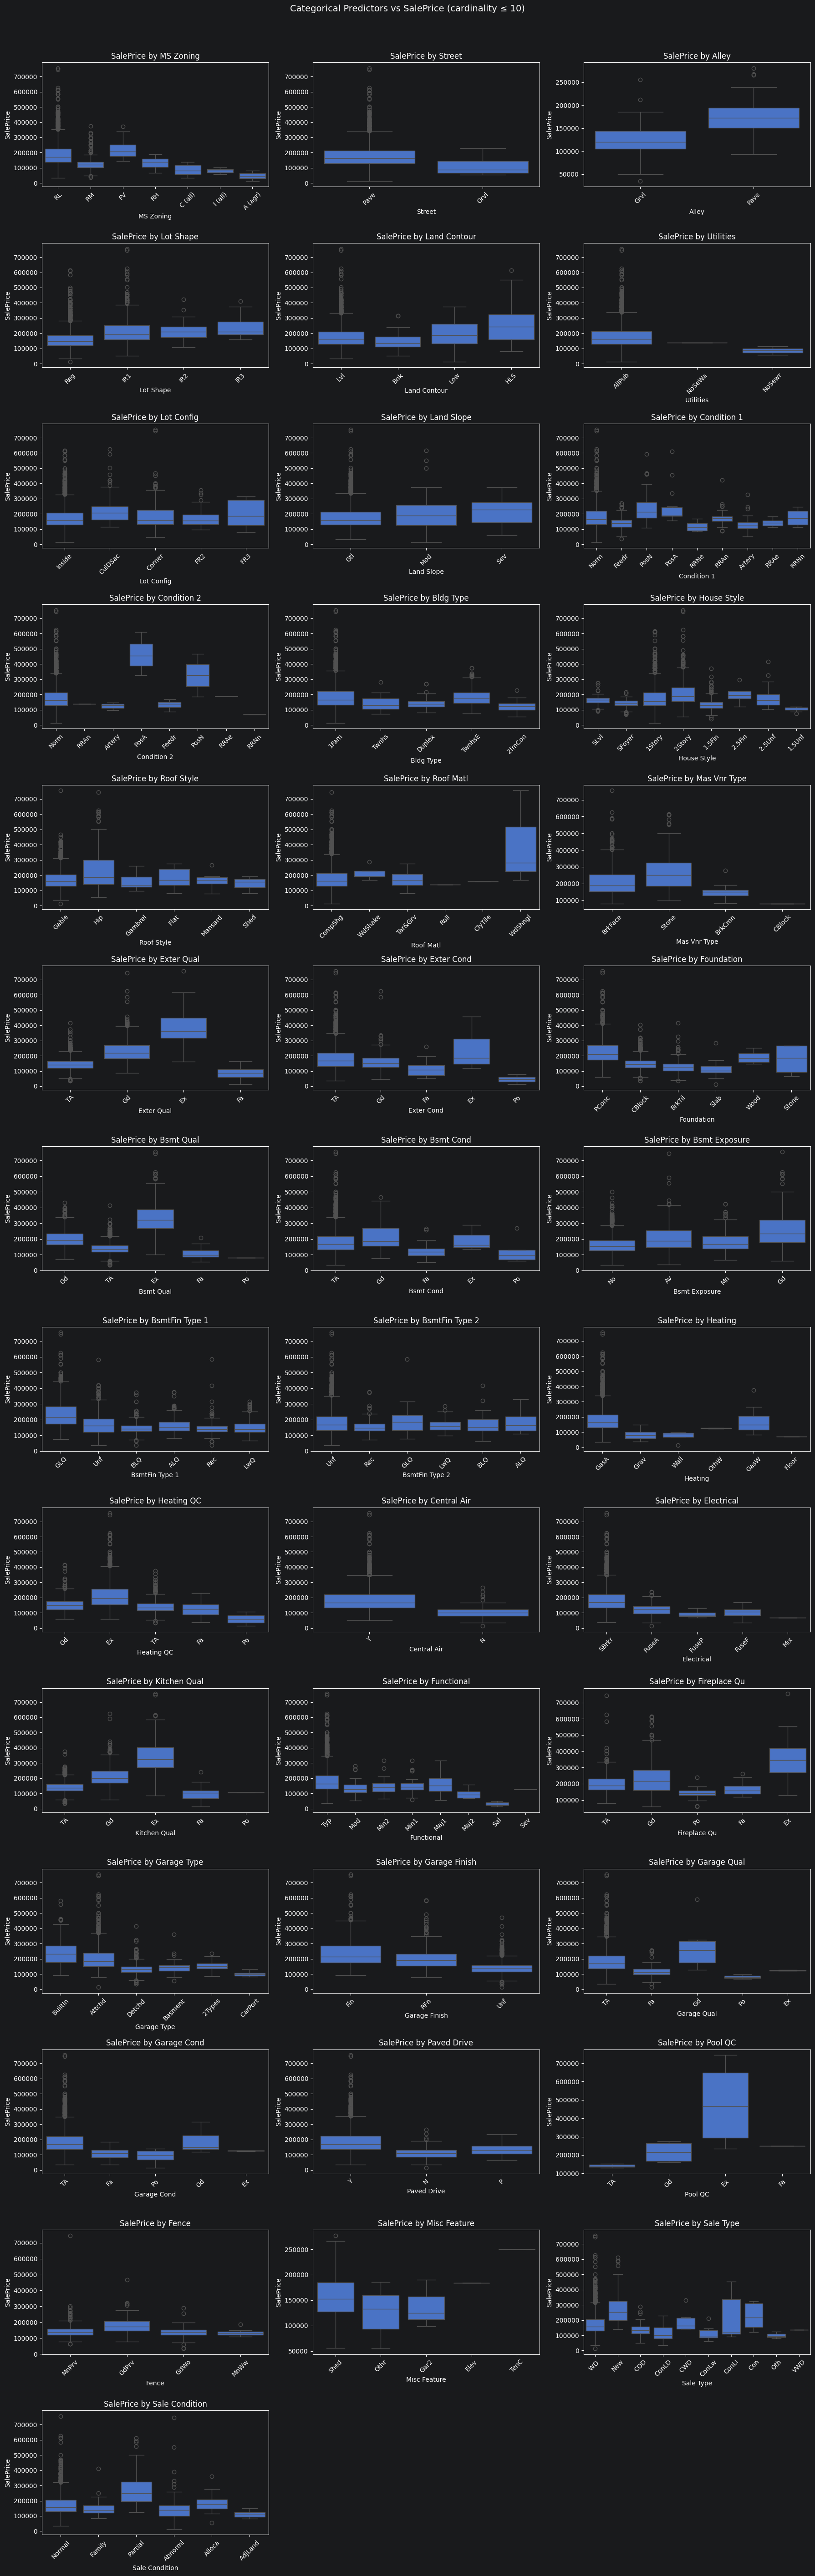

In [32]:
cat_cols_low_card = categorical_report[categorical_report['cardinality'] <= 10]['variable'].tolist()

n = len(cat_cols_low_card)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_low_card):
    sns.boxplot(data=df_train, x=col, y='SalePrice', ax=axes[i])
    axes[i].set_title(f"SalePrice by {col}")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Predictors vs SalePrice (cardinality ≤ 10)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [33]:
vif_candidates = corr_target_pearson.drop('SalePrice').abs().sort_values(ascending=False).head(10).index.tolist()

X_vif = df_train[vif_candidates].dropna()
X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_df = vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False)
vif_df

,variable,VIF
10,Garage Yr Blt,4.213521
3,Garage Cars,4.205721
4,Garage Area,4.179750
7,Year Built,4.030308
6,1st Flr SF,3.447410
5,Total Bsmt SF,3.286127
2,Gr Liv Area,2.647758
1,Overall Qual,2.591712
8,Full Bath,2.154985
9,Year Remod/Add,2.012954


In [34]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    n = table.sum().sum()
    k = min(table.shape)
    if k <= 1:
        return np.nan
    chi2, p, dof, _ = chi2_contingency(table)
    return np.sqrt(chi2 / (n * (k - 1)))

cat_cols_for_cramers = categorical_report[categorical_report['cardinality'] <= 15]['variable'].tolist()

pairs = []
for i, col1 in enumerate(cat_cols_for_cramers):
    for col2 in cat_cols_for_cramers[i+1:]:
        v = cramers_v(df_train[col1], df_train[col2])
        if not np.isnan(v):
            pairs.append({'var1': col1, 'var2': col2, 'cramers_v': round(v, 3)})

cramers_pairs = pd.DataFrame(pairs).sort_values('cramers_v', ascending=False)
cramers_pairs.head(20)

,var1,var2,cramers_v
835,Pool QC,Fence,0.816
1,MS Zoning,Alley,0.791
785,Functional,Pool QC,0.760
707,BsmtFin Type 2,Pool QC,0.736
409,House Style,Pool QC,0.729
471,Exterior 1st,Exterior 2nd,0.728
546,Mas Vnr Type,Misc Feature,0.709
544,Mas Vnr Type,Pool QC,0.707
795,Fireplace Qu,Pool QC,0.707
690,BsmtFin Type 1,Pool QC,0.677


## 15. Feature Engineering and Modeling Preparation

This
section
prepares
the
data
for multiple linear regression, including:
    - Handling
    missing
    values
    based
    on
    previous
    MCAR / MAR
    analysis
- Creating
derived
features
- Encoding
categorical
variables

In [35]:
# Trabalhar com cópias para não contaminar os dados originais
train_model = df_train.copy()
val_model = df.loc[X_val.index].copy()
test_model = df.loc[X_test.index].copy()

# =========================================================
# 1. Missing estruturais
# =========================================================

# Categóricos estruturais: NA = ausência da feature
structural_categorical = [
    'Alley',
    'Mas Vnr Type',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
    'BsmtFin Type 1', 'BsmtFin Type 2',
    'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Pool QC', 'Fence', 'Misc Feature'
]

# Numéricos estruturais: NA = ausência da feature -> 0
structural_numeric = [
    'Mas Vnr Area',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
    'Bsmt Full Bath', 'Bsmt Half Bath',
    'Garage Yr Blt', 'Garage Cars', 'Garage Area'
]

for df_ in [train_model, val_model, test_model]:
    for col in structural_categorical:
        if col in df_.columns:
            df_[col] = df_[col].fillna('None')

    for col in structural_numeric:
        if col in df_.columns:
            df_[col] = df_[col].fillna(0)

# =========================================================
# 2. Feature engineering coerente com missing estrutural
# =========================================================

# Indicador explícito de existência de garagem
for df_ in [train_model, val_model, test_model]:
    if 'Garage Area' in df_.columns:
        df_['Has_Garage'] = (df_['Garage Area'] > 0).astype(int)

# =========================================================
# 3. Missing não estruturais
# =========================================================

# Lot Frontage: MAR -> imputação pela mediana por Neighborhood
lot_frontage_medians = train_model.groupby('Neighborhood')['Lot Frontage'].median()

# fallback global calculado no treino
global_lot_frontage_median = train_model['Lot Frontage'].median()

def impute_lot_frontage(df, medians, global_median):
    df = df.copy()
    missing_idx = df['Lot Frontage'].isna()

    df.loc[missing_idx, 'Lot Frontage'] = (
        df.loc[missing_idx, 'Neighborhood']
        .map(medians)
        .fillna(global_median)
    )
    return df

train_model = impute_lot_frontage(train_model, lot_frontage_medians, global_lot_frontage_median)
val_model = impute_lot_frontage(val_model, lot_frontage_medians, global_lot_frontage_median)
test_model = impute_lot_frontage(test_model, lot_frontage_medians, global_lot_frontage_median)

# Electrical: 1 missing -> assumir MCAR e imputar com moda do treino
electrical_mode = train_model['Electrical'].mode()[0]

for df_ in [train_model, val_model, test_model]:
    if 'Electrical' in df_.columns:
        df_['Electrical'] = df_['Electrical'].fillna(electrical_mode)

# =========================================================
# 4. Verificação final
# =========================================================
print("Missing values remaining in train:")
print(train_model.isnull().sum()[train_model.isnull().sum() > 0])

print("\nMissing values remaining in validation:")
print(val_model.isnull().sum()[val_model.isnull().sum() > 0])

print("\nMissing values remaining in test:")
print(test_model.isnull().sum()[test_model.isnull().sum() > 0])

Missing values remaining in train:
Series([], dtype: int64)

Missing values remaining in validation:
Series([], dtype: int64)

Missing values remaining in test:
Series([], dtype: int64)


## 16. Feature Engineering

Creating
interpretable
derived
features
based
on
domain
knowledge.

In [36]:
# --- Área total ---
train_model['Total_SF'] = train_model['Total Bsmt SF'] + train_model['Gr Liv Area']
val_model['Total_SF'] = val_model['Total Bsmt SF'] + val_model['Gr Liv Area']
test_model['Total_SF'] = test_model['Total Bsmt SF'] + test_model['Gr Liv Area']

# --- Idade da casa no momento da venda ---
train_model['House_Age'] = train_model['Yr Sold'] - train_model['Year Built']
val_model['House_Age'] = val_model['Yr Sold'] - val_model['Year Built']
test_model['House_Age'] = test_model['Yr Sold'] - test_model['Year Built']

# --- Anos desde remodelação ---
train_model['Years_Since_Remod'] = train_model['Yr Sold'] - train_model['Year Remod/Add']
val_model['Years_Since_Remod'] = val_model['Yr Sold'] - val_model['Year Remod/Add']
test_model['Years_Since_Remod'] = test_model['Yr Sold'] - test_model['Year Remod/Add']

# --- Total de casas de banho ---
train_model['Total_Bath'] = (train_model['Full Bath'] + 0.5 * train_model['Half Bath'] +
                             train_model['Bsmt Full Bath'] + 0.5 * train_model['Bsmt Half Bath'])
val_model['Total_Bath'] = (val_model['Full Bath'] + 0.5 * val_model['Half Bath'] +
                           val_model['Bsmt Full Bath'] + 0.5 * val_model['Bsmt Half Bath'])
test_model['Total_Bath'] = (test_model['Full Bath'] + 0.5 * test_model['Half Bath'] +
                            test_model['Bsmt Full Bath'] + 0.5 * test_model['Bsmt Half Bath'])

# --- Qualidade geral (Overall Qual * Overall Cond) ---
train_model['Qual_Cond'] = train_model['Overall Qual'] * train_model['Overall Cond']
val_model['Qual_Cond'] = val_model['Overall Qual'] * val_model['Overall Cond']
test_model['Qual_Cond'] = test_model['Overall Qual'] * test_model['Overall Cond']

# --- Log transform do target (SalePrice é right-skewed) ---
train_model['log_SalePrice'] = np.log(train_model['SalePrice'])
val_model['log_SalePrice'] = np.log(val_model['SalePrice'])
test_model['log_SalePrice'] = np.log(test_model['SalePrice'])

# Verificar as novas features
train_model[['Total_SF', 'House_Age', 'Years_Since_Remod', 'Total_Bath', 'Qual_Cond', 'log_SalePrice']].describe()

,Total_SF,House_Age,Years_Since_Remod,Total_Bath,Qual_Cond,log_SalePrice
count,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000
mean,2556.921989,36.232082,23.346173,2.225987,33.891760,12.026308
std,832.564179,30.413825,20.936352,0.813905,9.089151,0.405545
min,612.000000,-1.000000,-2.000000,1.000000,1.000000,9.480368
25%,2004.000000,7.000000,4.000000,2.000000,30.000000,11.774905
50%,2446.000000,34.000000,15.000000,2.000000,35.000000,11.995352
75%,2999.500000,54.000000,42.000000,2.500000,40.000000,12.271977
max,11752.000000,136.000000,60.000000,7.000000,90.000000,13.534473


## 17. Model 1: Simple Linear Regression (Baseline)

Starting
with the single strongest predictor to establish a baseline.

In [42]:
# Baseline: apenas Overall Qual (correlação mais forte com SalePrice)
model1 = smf.ols('log_SalePrice ~ Q("Overall Qual") + Total_SF + House_Age', data=train_model).fit()
print(model1.summary())

# Avaliar no validation set
val_model['pred_model1'] = model1.predict(val_model)

rmse_model1 = np.sqrt(mean_squared_error(val_model['log_SalePrice'], val_model['pred_model1']))
print(f"Model 1 - RMSE (log scale): {rmse_model1:.4f}")

# Converter para escala original para interpretação
val_model['pred_model1_original'] = np.exp(val_model['pred_model1'])
rmse_model1_original = np.sqrt(mean_squared_error(val_model['SalePrice'], val_model['pred_model1_original']))
print(f"Model 1 - RMSE (original scale): ${rmse_model1_original:,.0f}")

                            OLS Regression Results                            
Dep. Variable:          log_SalePrice   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     2864.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:50:38   Log-Likelihood:                 631.55
No. Observations:                2051   AIC:                            -1255.
Df Residuals:                    2047   BIC:                            -1233.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            10.8464      0.02

## 18. Model 2: Multiple Numeric Predictors

Adding
top
correlated
numeric
features
based
on
EDA
findings.

In [47]:
# Modelo com variáveis numéricas de alta correlação
formula_model2 = '''
log_SalePrice ~ Q("Overall Qual")
                + np.log(Total_SF)
                + np.log(Q("Lot Area"))
                + np.log(Q("Garage Area") + 1)
                + Total_Bath
                + House_Age
'''

model2 = smf.ols(formula_model2, data=train_model).fit()
print(model2.summary())

# Avaliar no validation set
val_model['pred_model2'] = model2.predict(val_model)

rmse_model2 = np.sqrt(mean_squared_error(val_model['log_SalePrice'], val_model['pred_model2']))
print(f"Model 2 - RMSE (log scale): {rmse_model2:.4f}")

val_model['pred_model2_original'] = np.exp(val_model['pred_model2'])
rmse_model2_original = np.sqrt(mean_squared_error(val_model['SalePrice'], val_model['pred_model2_original']))
print(f"Model 2 - RMSE (original scale): ${rmse_model2_original:,.0f}")

# VIF para verificar multicolinearidade
X_model2 = train_model.copy()
X_model2 = pd.DataFrame({
    'Overall_Qual': X_model2['Overall Qual'],
    'log_Total_SF': np.log(X_model2['Total_SF']),
    'log_Lot_Area': np.log(X_model2['Lot Area']),
    'log_Garage_Area': np.log(X_model2['Garage Area'] + 1),
    'Total_Bath': X_model2['Total_Bath'],
    'House_Age': X_model2['House_Age']
}).dropna()

X_model2 = sm.add_constant(X_model2)

vif_model2 = pd.DataFrame({
    'variable': X_model2.columns,
    'VIF': [variance_inflation_factor(X_model2.values, i) for i in range(X_model2.shape[1])]
})
vif_model2 = vif_model2[vif_model2['variable'] != 'const'].sort_values('VIF', ascending=False)
print("\nVIF Analysis:")
print(vif_model2)

                            OLS Regression Results                            
Dep. Variable:          log_SalePrice   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     2035.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:16:31   Log-Likelihood:                 932.89
No. Observations:                2051   AIC:                            -1852.
Df Residuals:                    2044   BIC:                            -1812.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## 19. Model 3: Adding Categorical Predictors

Including
neighborhood and other
categorical
features
with strong association to SalePrice.

In [50]:
# Agrupar categorias raras com base APENAS no treino
def group_rare_from_train(train_series, other_series_list=None, threshold=0.05):
    freq = train_series.value_counts(normalize=True)
    rare_levels = freq[freq < threshold].index.tolist()

    train_grouped = train_series.apply(lambda x: 'Other' if x in rare_levels else x)

    grouped_others = []
    if other_series_list is not None:
        for s in other_series_list:
            grouped_others.append(s.apply(lambda x: 'Other' if x in rare_levels else x))

    return train_grouped, grouped_others, rare_levels


# Neighborhood
train_model['Neighborhood_grouped'], grouped_sets, rare_neighborhoods = group_rare_from_train(
    train_model['Neighborhood'],
    [val_model['Neighborhood'], test_model['Neighborhood']],
    threshold=0.05
)

val_model['Neighborhood_grouped'] = grouped_sets[0]
test_model['Neighborhood_grouped'] = grouped_sets[1]

In [51]:
# Modelo com variáveis categóricas
formula_model3 = '''
log_SalePrice ~ Q("Overall Qual")
                + np.log(Total_SF)
                + np.log(Q("Lot Area"))
                + np.log(Q("Garage Area") + 1)
                + Total_Bath
                + House_Age
                + C(Neighborhood_grouped)
                + C(Q("Bldg Type"))
                + C(Q("Kitchen Qual"))
'''

model3 = smf.ols(formula_model3, data=train_model).fit()
print(model3.summary())

# Avaliar no validation set
val_model['pred_model3'] = model3.predict(val_model)

rmse_model3 = np.sqrt(mean_squared_error(val_model['log_SalePrice'], val_model['pred_model3']))
print(f"Model 3 - RMSE (log scale): {rmse_model3:.4f}")

val_model['pred_model3_original'] = np.exp(val_model['pred_model3'])
rmse_model3_original = np.sqrt(mean_squared_error(val_model['SalePrice'], val_model['pred_model3_original']))
print(f"Model 3 - RMSE (original scale): ${rmse_model3_original:,.0f}")

                            OLS Regression Results                            
Dep. Variable:          log_SalePrice   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     620.5
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:31:30   Log-Likelihood:                 1038.7
No. Observations:                2051   AIC:                            -2031.
Df Residuals:                    2028   BIC:                            -1902.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [56]:
def simplify_neighborhood(series):
    high_value = ['NridgHt', 'Somerst']
    return series.apply(lambda x: 'High' if x in high_value else 'Other')

for df_ in [train_model, val_model, test_model]:
    df_['Neighborhood_simple'] = simplify_neighborhood(df_['Neighborhood_grouped'])

In [57]:
def simplify_bldg_type(series):
    return series.apply(lambda x: 'Detached' if x == '1Fam' else 'Other')

for df_ in [train_model, val_model, test_model]:
    df_['Bldg_Type_simple'] = simplify_bldg_type(df_['Bldg Type'])

In [58]:
val_model['pred_model4'] = model4.predict(val_model)

rmse_model4 = np.sqrt(mean_squared_error(val_model['log_SalePrice'], val_model['pred_model4']))
print(f"Model 4 - RMSE (log scale): {rmse_model4:.4f}")

val_model['pred_model4_original'] = np.exp(val_model['pred_model4'])
rmse_model4_original = np.sqrt(mean_squared_error(val_model['SalePrice'], val_model['pred_model4_original']))
print(f"Model 4 - RMSE (original scale): ${rmse_model4_original:,.0f}")

Model 4 - RMSE (log scale): 0.1694
Model 4 - RMSE (original scale): $25,610


In [59]:
X_model4 = pd.DataFrame({
    'Overall_Qual': train_model['Overall Qual'],
    'log_Total_SF': np.log(train_model['Total_SF']),
    'log_Lot_Area': np.log(train_model['Lot Area']),
    'log_Garage_Area': np.log(train_model['Garage Area'] + 1),
    'Total_Bath': train_model['Total_Bath'],
    'House_Age': train_model['House_Age']
}).dropna()

X_model4 = sm.add_constant(X_model4)

vif_model4 = pd.DataFrame({
    'variable': X_model4.columns,
    'VIF': [variance_inflation_factor(X_model4.values, i) for i in range(X_model4.shape[1])]
})

vif_model4 = vif_model4[vif_model4['variable'] != 'const'].sort_values('VIF', ascending=False)

print("\nVIF Analysis:")
print(vif_model4)


VIF Analysis:
          variable       VIF
2     log_Total_SF  2.635506
1     Overall_Qual  2.500004
5       Total_Bath  1.920729
6        House_Age  1.822149
3     log_Lot_Area  1.279079
4  log_Garage_Area  1.227257


In [60]:
formula_model4 = '''
log_SalePrice ~ Q("Overall Qual")
                + np.log(Total_SF)
                + np.log(Q("Lot Area"))
                + np.log(Q("Garage Area") + 1)
                + Total_Bath
                + House_Age
                + C(Neighborhood_simple)
                + C(Kitchen_Qual_grouped)
                + C(Bldg_Type_simple)
'''

model4 = smf.ols(formula_model4, data=train_model).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:          log_SalePrice   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     1300.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:03:11   Log-Likelihood:                 989.94
No. Observations:                2051   AIC:                            -1958.
Df Residuals:                    2040   BIC:                            -1896.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [61]:
# =========================================================
# Modelo 5: interação entre Neighborhood e área (Total_SF)
# =========================================================

formula_model5 = '''
log_SalePrice ~ Q("Overall Qual")
                + np.log(Total_SF)
                + np.log(Q("Lot Area"))
                + np.log(Q("Garage Area") + 1)
                + Total_Bath
                + House_Age
                + C(Neighborhood_simple)
                + C(Kitchen_Qual_grouped)
                + C(Bldg_Type_simple)
                + C(Neighborhood_simple):np.log(Total_SF)
'''

model5 = smf.ols(formula_model5, data=train_model).fit()
print(model5.summary())


# --- Avaliação ---
val_model['pred_model5'] = model5.predict(val_model)

rmse_model5 = np.sqrt(mean_squared_error(val_model['log_SalePrice'], val_model['pred_model5']))
print(f"Model 5 - RMSE (log scale): {rmse_model5:.4f}")

val_model['pred_model5_original'] = np.exp(val_model['pred_model5'])
rmse_model5_original = np.sqrt(mean_squared_error(val_model['SalePrice'], val_model['pred_model5_original']))
print(f"Model 5 - RMSE (original scale): ${rmse_model5_original:,.0f}")

                            OLS Regression Results                            
Dep. Variable:          log_SalePrice   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     1204.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:14:22   Log-Likelihood:                 1007.1
No. Observations:                2051   AIC:                            -1990.
Df Residuals:                    2039   BIC:                            -1923.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [62]:
# =========================================================
# VIF correto para modelo com categóricas + interação
# =========================================================

X = model5.model.exog
feature_names = model5.model.exog_names

vif_model5 = pd.DataFrame({
    'variable': feature_names,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})

vif_model5 = vif_model5[vif_model5['variable'] != 'Intercept']
vif_model5 = vif_model5.sort_values('VIF', ascending=False)

print("\nVIF Analysis:")
print(vif_model5)


VIF Analysis:
                                            variable          VIF
1                    C(Neighborhood_simple)[T.Other]  1168.237324
7   C(Neighborhood_simple)[T.Other]:np.log(Total_SF)  1108.054642
6                                   np.log(Total_SF)    17.535733
5                                  Q("Overall Qual")     2.989333
10                                        Total_Bath     2.023509
11                                         House_Age     2.001880
8                              np.log(Q("Lot Area"))     1.858495
3                  C(Kitchen_Qual_grouped)[T.Medium]     1.770883
4                       C(Bldg_Type_simple)[T.Other]     1.604923
9                       np.log(Q("Garage Area") + 1)     1.256265
2                     C(Kitchen_Qual_grouped)[T.Low]     1.230964


In [63]:
# =========================================================
# Modelo 6: modelo reduzido (core features)
# =========================================================

formula_model6 = '''
log_SalePrice ~ Q("Overall Qual")
                + np.log(Total_SF)
                + C(Neighborhood_simple)
                + C(Kitchen_Qual_grouped)
'''

model6 = smf.ols(formula_model6, data=train_model).fit()
print(model6.summary())


# --- Avaliação ---
val_model['pred_model6'] = model6.predict(val_model)

rmse_model6 = np.sqrt(mean_squared_error(val_model['log_SalePrice'], val_model['pred_model6']))
print(f"Model 6 - RMSE (log scale): {rmse_model6:.4f}")

val_model['pred_model6_original'] = np.exp(val_model['pred_model6'])
rmse_model6_original = np.sqrt(mean_squared_error(val_model['SalePrice'], val_model['pred_model6_original']))
print(f"Model 6 - RMSE (original scale): ${rmse_model6_original:,.0f}")

                            OLS Regression Results                            
Dep. Variable:          log_SalePrice   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     1833.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:18:13   Log-Likelihood:                 686.27
No. Observations:                2051   AIC:                            -1361.
Df Residuals:                    2045   BIC:                            -1327.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [64]:
X_model6 = pd.DataFrame({
    'Overall_Qual': train_model['Overall Qual'],
    'log_Total_SF': np.log(train_model['Total_SF'])
}).dropna()

X_model6 = sm.add_constant(X_model6)

vif_model6 = pd.DataFrame({
    'variable': X_model6.columns,
    'VIF': [variance_inflation_factor(X_model6.values, i) for i in range(X_model6.shape[1])]
})

vif_model6 = vif_model6[vif_model6['variable'] != 'const'].sort_values('VIF', ascending=False)

print("\nVIF Analysis:")
print(vif_model6)


VIF Analysis:
       variable      VIF
2  log_Total_SF  1.82995
1  Overall_Qual  1.82995


In [65]:
df_model = df.copy()

df_model["price_tier"] = pd.qcut(
    df_model["SalePrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df_model["is_high"] = (df_model["price_tier"] == "High").astype(int)

In [66]:
print(df_model["price_tier"].value_counts())
print(df_model["is_high"].value_counts(normalize=True))

price_tier
Low       981
Medium    980
High      969
Name: count, dtype: int64
is_high
0    0.669283
1    0.330717
Name: proportion, dtype: float64


In [68]:
q1, q2 = train_model["SalePrice"].quantile([1/3, 2/3])

def assign_price_tier(price, q1, q2):
    if price <= q1:
        return "Low"
    elif price <= q2:
        return "Medium"
    return "High"

for df_ in [train_model, val_model, test_model]:
    df_["price_tier"] = df_["SalePrice"].apply(lambda x: assign_price_tier(x, q1, q2))
    df_["is_high"] = (df_["price_tier"] == "High").astype(int)

print(train_model["price_tier"].value_counts())
print(train_model["is_high"].value_counts(normalize=True))

price_tier
Low       705
High      676
Medium    670
Name: count, dtype: int64
is_high
0    0.670405
1    0.329595
Name: proportion, dtype: float64


In [69]:
import statsmodels.formula.api as smf

formula_logit1 = '''
is_high ~ Q("Overall Qual") + np.log(Total_SF)
'''

model_logit1 = smf.logit(formula_logit1, data=train_model).fit()
print(model_logit1.summary())

Optimization terminated successfully.
         Current function value: 0.248732
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                is_high   No. Observations:                 2051
Model:                          Logit   Df Residuals:                     2048
Method:                           MLE   Df Model:                            2
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.6076
Time:                        22:37:56   Log-Likelihood:                -510.15
converged:                       True   LL-Null:                       -1300.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -74.4692      4.230    -17.605      0.000     -82.760     -66.178
Q("Overa

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Probabilidades
val_model['pred_prob_1'] = model_logit1.predict(val_model)

# Classificação (threshold 0.5)
val_model['pred_class_1'] = (val_model['pred_prob_1'] >= 0.4).astype(int)

print(confusion_matrix(val_model['is_high'], val_model['pred_class_1']))
print(classification_report(val_model['is_high'], val_model['pred_class_1']))

# ROC-AUC
auc = roc_auc_score(val_model['is_high'], val_model['pred_prob_1'])
print(f"ROC-AUC: {auc:.4f}")

[[283  17]
 [ 24 115]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       300
           1       0.87      0.83      0.85       139

    accuracy                           0.91       439
   macro avg       0.90      0.89      0.89       439
weighted avg       0.91      0.91      0.91       439

ROC-AUC: 0.9607


In [72]:
# =========================================================
# Modelo Logit 2: baseline + Neighborhood + Kitchen Qual
# =========================================================

formula_logit2 = '''
is_high ~ Q("Overall Qual")
          + np.log(Total_SF)
          + C(Neighborhood_simple)
          + C(Kitchen_Qual_grouped)
'''

model_logit2 = smf.logit(formula_logit2, data=train_model).fit()
print(model_logit2.summary())


# --- Avaliação no validation set ---
val_model['pred_prob_2'] = model_logit2.predict(val_model)

# threshold ajustado (mantendo a lógica que funcionou melhor no baseline)
threshold = 0.4
val_model['pred_class_2'] = (val_model['pred_prob_2'] >= threshold).astype(int)

print(confusion_matrix(val_model['is_high'], val_model['pred_class_2']))
print(classification_report(val_model['is_high'], val_model['pred_class_2']))

auc_2 = roc_auc_score(val_model['is_high'], val_model['pred_prob_2'])
print(f"ROC-AUC: {auc_2:.4f}")

Optimization terminated successfully.
         Current function value: 0.224823
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_high   No. Observations:                 2051
Model:                          Logit   Df Residuals:                     2045
Method:                           MLE   Df Model:                            5
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.6453
Time:                        22:54:46   Log-Likelihood:                -461.11
converged:                       True   LL-Null:                       -1300.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -75.6781      4.511    -16

In [74]:
# =========================================================
# Modelo Logit 3: Logit 2 + variáveis numéricas adicionais
# =========================================================

formula_logit3 = '''
is_high ~ Q("Overall Qual")
          + np.log(Total_SF)
          + np.log(Q("Lot Area"))
          + np.log(Q("Garage Area") + 1)
          + Total_Bath
          + House_Age
          + C(Neighborhood_simple)
          + C(Kitchen_Qual_grouped)
'''

model_logit3 = smf.logit(formula_logit3, data=train_model).fit()
print(model_logit3.summary())


# --- Avaliação no validation set ---
val_model['pred_prob_3'] = model_logit3.predict(val_model)

threshold = 0.4
val_model['pred_class_3'] = (val_model['pred_prob_3'] >= threshold).astype(int)

print(confusion_matrix(val_model['is_high'], val_model['pred_class_3']))
print(classification_report(val_model['is_high'], val_model['pred_class_3']))

auc_3 = roc_auc_score(val_model['is_high'], val_model['pred_prob_3'])
print(f"ROC-AUC: {auc_3:.4f}")


Optimization terminated successfully.
         Current function value: 0.202187
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_high   No. Observations:                 2051
Model:                          Logit   Df Residuals:                     2041
Method:                           MLE   Df Model:                            9
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.6810
Time:                        08:27:38   Log-Likelihood:                -414.69
converged:                       True   LL-Null:                       -1300.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -79.5572      4.975    -15

In [73]:

# --- Odds ratios ---
odds_ratios_3 = pd.DataFrame({
    'variable': model_logit3.params.index,
    'coef': model_logit3.params.values,
    'odds_ratio': np.exp(model_logit3.params.values)
})
print("\nOdds Ratios:")
print(odds_ratios_3)

Optimization terminated successfully.
         Current function value: 0.202187
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_high   No. Observations:                 2051
Model:                          Logit   Df Residuals:                     2041
Method:                           MLE   Df Model:                            9
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.6810
Time:                        08:27:21   Log-Likelihood:                -414.69
converged:                       True   LL-Null:                       -1300.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -79.5572      4.975    -15

In [76]:
# =========================================================
# Modelo Logit 4: versão refinada / mais parsimoniosa
# Remove variáveis fracas do Logit 3
# =========================================================

formula_logit4 = '''
is_high ~ Q("Overall Qual")
          + np.log(Total_SF)
          + np.log(Q("Lot Area"))
          + Total_Bath
          + House_Age
          + C(Neighborhood_simple)
          + C(Kitchen_Qual_grouped)
'''

model_logit4 = smf.logit(formula_logit4, data=train_model).fit()
print(model_logit4.summary())


# --- Avaliação no validation set ---
val_model['pred_prob_4'] = model_logit4.predict(val_model)

threshold = 0.4
val_model['pred_class_4'] = (val_model['pred_prob_4'] >= threshold).astype(int)

print(confusion_matrix(val_model['is_high'], val_model['pred_class_4']))
print(classification_report(val_model['is_high'], val_model['pred_class_4']))

auc_4 = roc_auc_score(val_model['is_high'], val_model['pred_prob_4'])
print(f"ROC-AUC: {auc_4:.4f}")

Optimization terminated successfully.
         Current function value: 0.203351
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_high   No. Observations:                 2051
Model:                          Logit   Df Residuals:                     2042
Method:                           MLE   Df Model:                            8
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.6792
Time:                        08:29:50   Log-Likelihood:                -417.07
converged:                       True   LL-Null:                       -1300.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -78.9863      4.929    -16

In [75]:


# --- Odds ratios ---
odds_ratios_4 = pd.DataFrame({
    'variable': model_logit4.params.index,
    'coef': model_logit4.params.values,
    'odds_ratio': np.exp(model_logit4.params.values)
})
print("\nOdds Ratios:")
print(odds_ratios_4)

Optimization terminated successfully.
         Current function value: 0.203351
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_high   No. Observations:                 2051
Model:                          Logit   Df Residuals:                     2042
Method:                           MLE   Df Model:                            8
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.6792
Time:                        08:29:38   Log-Likelihood:                -417.07
converged:                       True   LL-Null:                       -1300.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                           -78.9863      4.929    -16

In [77]:
# =========================================================
# Modelo Logit Final: sem Kitchen Qual
# =========================================================

formula_logit_final = '''
is_high ~ Q("Overall Qual")
          + np.log(Total_SF)
          + np.log(Q("Lot Area"))
          + Total_Bath
          + House_Age
          + C(Neighborhood_simple)
'''

model_logit_final = smf.logit(formula_logit_final, data=train_model).fit()
print(model_logit_final.summary())


# --- Avaliação no validation set ---
val_model['pred_prob_final'] = model_logit_final.predict(val_model)

threshold = 0.4
val_model['pred_class_final'] = (val_model['pred_prob_final'] >= threshold).astype(int)

print(confusion_matrix(val_model['is_high'], val_model['pred_class_final']))
print(classification_report(val_model['is_high'], val_model['pred_class_final']))

auc_final = roc_auc_score(val_model['is_high'], val_model['pred_prob_final'])
print(f"ROC-AUC: {auc_final:.4f}")

Optimization terminated successfully.
         Current function value: 0.213737
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_high   No. Observations:                 2051
Model:                          Logit   Df Residuals:                     2044
Method:                           MLE   Df Model:                            6
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.6628
Time:                        08:31:55   Log-Likelihood:                -438.37
converged:                       True   LL-Null:                       -1300.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         -78.4112      4.763    -16.464  